# Support Vector Machine (SVM)

In [9]:
from datetime import datetime
from scipy.sparse import load_npz, hstack, csr_matrix
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import pandas as pd

## Carga del dataset

Se cargan los conjuntos de entrenamiento y prueba preprocesados del EDA. En este caso sólo se utilizan las **características TF-IDF**, vectores de alta dimensionalidad generados por `TfidfVectorizer`. Ya que es la configuración típica en literatura de phishing con modelos SVM, donde la información textual es suficiente para realizar la separación.

In [10]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

## Preprocesamiento y Estandarización

Dado que KNN calcula distancias entre vectores, no soporta valores no numéricos, también requiere estandarización para evitar que características con magnitudes mayores dominen. Se utiliza StandardScaler (con `mean=False`) para evitar que la matriz se haga más densa de valores.

In [11]:
scaler_tfidf = StandardScaler(with_mean=False)

X_train = scaler_tfidf.fit_transform(X_train)
X_test = scaler_tfidf.transform(X_test)

## Modelo SVM con Kernel RBF

* **Kernel RBF**: Kernel RBF recomendado por la documentación consultada. Soporta separabilidad no lineal. En espacios TF-IDF de alta dimensionalidad, es más común que las clases no sean linealmente separables.
* **probability=True**: Para calcular métricas de confianza y generar curvas ROC para análisis de desempeño.

In [12]:
svc_model = SVC(kernel='rbf', probability=True)

start_train = datetime.now()
svc_model.fit(X_train, y_train)
train_duration = datetime.now() - start_train

start_pred = datetime.now()
y_pred = svc_model.predict(X_test)
predict_duration = datetime.now() - start_pred

## Evaluación del Modelo

Se evalúa el desempeño del modelo entrenado mediante matriz de confusión y métricas de clasificación. Dado que hay cierto desbalance de clases en el problema (aproximadamente 38% de correos son phishing), se utiliza la exactitud balanceada.

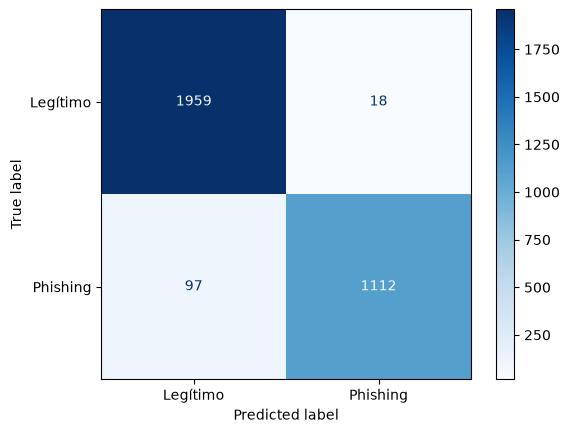

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [14]:
cm_svc_model = confusion_matrix(y_test, y_pred)
P = cm_svc_model[1, :].sum()
N = cm_svc_model[0, :].sum()
TP = cm_svc_model[1, 1]
TN = cm_svc_model[0, 0]

TPR_svm = TP / P
TNR_svm = TN / N
balanced_accuracy_svm = (TPR_svm + TNR_svm) / 2

precision_svm = precision_score(y_test, y_pred, zero_division=0)
recall_svm = recall_score(y_test, y_pred, zero_division=0)
f1_svm = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_svm:.4f}")
print(f"Precisión:               {precision_svm:.4f}")
print(f"Sensibilidad (Recall):   {TPR_svm:.4f}")
print(f"F1-score:                {f1_svm:.4f}")
print(f"Especificidad:           {TNR_svm:.4f}")
print(f"Recuperación (Recall):   {recall_svm:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.9553
Precisión:               0.9841
Sensibilidad (Recall):   0.9198
F1-score:                0.9508
Especificidad:           0.9909
Recuperación (Recall):   0.9198
Tiempo de entrenamiento: 0:06:48.772140
Tiempo de predicción:    0:00:09.513383


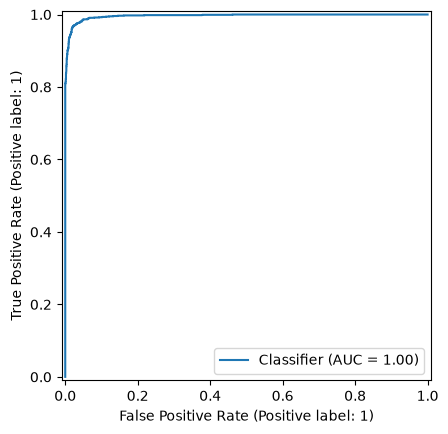

In [15]:
y_scores = svc_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Es un resultado muy aceptable.

## Análisis de Vectores de Soporte

Son los ejemplos críticos cerca del hiperplano que definen la frontera de decisión. Su cantidad por clase indica complejidad de separación: más vectores sugieren fronteras más complejas.

<BarContainer object of 2 artists>

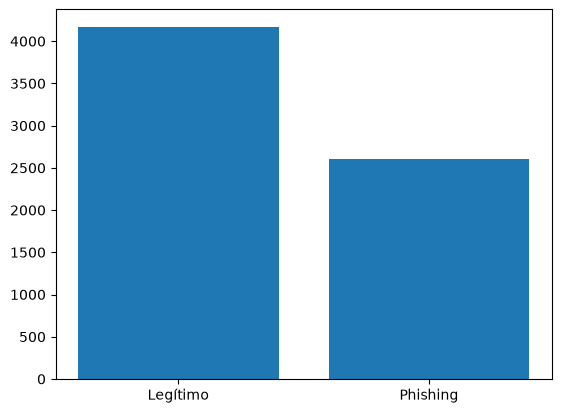

In [16]:
plt.bar(['Legítimo', 'Phishing'], svc_model.n_support_)

## Análisis de Resultados y Conclusiones

En esta notebook se ve que el modelo entrenado con los parámetros iniciales logra una separación óptima en el set de test. Se puede ver que el texto de los correos tiene patrones en el espacio generado con TF-IDF que logra separarlos por una frontera no lineal y que el modelo generaliza bien con datos no vistos.

En este caso no hizo falta utilizar un proceso de optimización de hiperparámetros ya que los resultados del modelo baseline fueron satisfactorios.

En cuanto a tiempos de entrenamiento, el modelo tiene un costo mayor a varios de los modelos vistos en el resto del trabajo, pero con muy buenos resultados y sin la necesidad de recurrir a la optimización de hiperparámetros.